In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [13]:
load_dotenv()

True

In [14]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [15]:
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num:float, second_num:float, operation:str) -> dict:
    """
    Performs basic arithmetic operations on two numbers.
    Supported operations: add, subtract, multiply, divide.
    """

    if operation == "add":
        result = first_num + second_num
    elif operation == "subtract":
        result = first_num - second_num
    elif operation == "multiply":
        result = first_num * second_num
    elif operation == "divide":
        if second_num == 0:
            return {"error": "Cannot divide by zero"}
        result = first_num / second_num
    else:
        return {"error": "Invalid operation"}
    
    return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetches the current stock price for a given symbol (e.g. 'AAPL', 'TSLA') using the Alpha Vantage API.
    """
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}"
    r = requests.get(url)
    return r.json()


In [16]:
# Make tool list
tools = [calculator, get_stock_price, search_tool]

# Make llm tool aware
llm_with_tools = llm.bind_tools(tools)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [18]:
def chat_node(state: ChatState):
    """LLM node that can answer questions and call tools"""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [36]:
# Graph

graph = StateGraph(ChatState)
graph.add_node("Chat Node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "Chat Node")
# tools_condition routes to "tools" when a tool call is needed, otherwise it routes to END.
graph.add_conditional_edges("Chat Node", tools_condition)
graph.add_edge("tools", "Chat Node")
# graph.add_edge("Chat Node", END)

In [37]:
workflow = graph.compile()

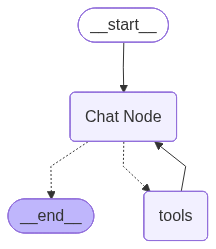

In [38]:
workflow

In [35]:
out = workflow.invoke({"messages":[HumanMessage(content="What is the stock price of Apple. How much would it cost to buy 10 shares?")]})

print(out["messages"])

[HumanMessage(content='What is the stock price of Apple. How much would it cost to buy 10 shares?', additional_kwargs={}, response_metadata={}, id='9afc31dc-4005-4686-9f89-5c7cfbd4c89d'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to fetch stock price for Apple, symbol AAPL. Use get_stock_price. Then calculate cost for 10 shares. Use calculator function.', 'tool_calls': [{'id': 'fc_33c4ebf7-42d9-4c07-8221-85c2fe658d50', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 255, 'total_tokens': 315, 'completion_time': 0.188872256, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.009977201, 'prompt_tokens_details': None, 'queue_time': 0.157205228, 'total_time': 0.198849457}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_974392087a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs'